In [1]:
import openslide
from PIL import Image
import os
import numpy as np
import torch
import torch.nn as nn
import tifffile
import pandas as pd
from skimage.transform import downscale_local_mean
from skimage import filters, color
from math import ceil
from tqdm import tqdm
from torchvision.transforms import Normalize, Compose
from einops import rearrange
import matplotlib.pyplot as plt
import random
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import timm
import glob
from torchvision import transforms
from timm import create_model
from huggingface_hub import login

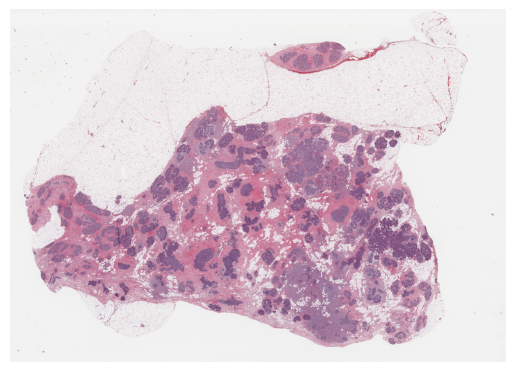

In [2]:
slide = openslide.OpenSlide("/tcga/open-access/gdc_data_portal/biospecimen/tcga_Biospecimen_FILES/7ea8749b-c86b-49ff-946c-625943f1d8e7/TCGA-GM-A3XG-01Z-00-DX1.68FFB600-8573-451F-8100-D11DB091F457.svs")

thumbnail = slide.get_thumbnail((1024, 1024))
plt.imshow(thumbnail)
plt.axis('off')
plt.show()

In [3]:
metadata_path = "/tcga/open-access/gdc_data_portal/biospecimen/tcga_Biospecimen_SAMPLE_METADATA/2023-09-01/gdc_sample_sheet.2023-09-05.tsv"

metadata_df = pd.read_csv(metadata_path, sep='\t')
metadata_df.head()

,File ID,File Name,Data Category,Data Type,Project ID,Case ID,Sample ID,Sample Type
0,23b65b33-60be-41b5-8e9b-c51cef2040e5,TCGA-OR-A5L4-01A-01-TS1.B83ABA93-F744-4816-9D1...,Biospecimen,Slide Image,TCGA-ACC,TCGA-OR-A5L4,TCGA-OR-A5L4-01A,Primary Tumor
1,7e81964c-b61f-405d-8d9e-fc5192ae1e59,nationwidechildrens.org_ssf.TCGA-OR-A5L3.xml,Biospecimen,Biospecimen Supplement,TCGA-ACC,TCGA-OR-A5L3,NaN,NaN
2,12dfcdc4-dd6e-48a3-b216-ea057a9ed4c0,TCGA-OR-A5LM-01Z-00-DX2.5EF0A814-B9F8-4BC5-BA6...,Biospecimen,Slide Image,TCGA-ACC,TCGA-OR-A5LM,TCGA-OR-A5LM-01Z,Primary Tumor
3,9b1ad009-d9f7-4645-a355-a3e2cff0b65c,TCGA-OR-A5LM-01Z-00-DX4.DF803EB7-FD51-47F6-8A4...,Biospecimen,Slide Image,TCGA-ACC,TCGA-OR-A5LM,TCGA-OR-A5LM-01Z,Primary Tumor
4,0bc80840-005f-4c56-a11e-df6843e54953,nationwidechildrens.org_biospecimen.TCGA-OR-A5...,Biospecimen,Biospecimen Supplement,TCGA-ACC,TCGA-OR-A5J1,NaN,NaN


In [4]:
slides_df = metadata_df[metadata_df['Data Type'] == 'Slide Image']
slides_df = slides_df.sort_values(by='Project ID').reset_index(drop=True)

In [5]:
base_dir = '/tcga/open-access/gdc_data_portal/biospecimen/tcga_Biospecimen_FILES/'

slides_df['Full Path'] = slides_df.apply(lambda row: os.path.join(base_dir, row['File ID'], row['File Name']), axis=1)

slides_df['Full Path'].head()

0    /tcga/open-access/gdc_data_portal/biospecimen/...
1    /tcga/open-access/gdc_data_portal/biospecimen/...
2    /tcga/open-access/gdc_data_portal/biospecimen/...
3    /tcga/open-access/gdc_data_portal/biospecimen/...
4    /tcga/open-access/gdc_data_portal/biospecimen/...
Name: Full Path, dtype: object

In [6]:
def crop(im, patch_size):
    height, width, _ = im.shape
    n_patches_h = height // patch_size
    n_patches_w = width // patch_size
    height_crop = patch_size * n_patches_h
    width_crop = patch_size * n_patches_w
    im = im[:height_crop, :width_crop, :]
    return im, n_patches_h, n_patches_w

# Segment function
def segment(thumb):
    im_gray = color.rgb2gray(thumb)
    thres = filters.threshold_otsu(im_gray)
    mask = im_gray < thres
    return mask

# Patchify function
def patchify(im, mask, patch_size, n_patches_h, n_patches_w):
    patches = []
    for i in range(n_patches_h):
        for j in range(n_patches_w):
            if not mask[i, j]:
                continue
            start_i = i * patch_size
            end_i = start_i + patch_size
            start_j = j * patch_size
            end_j = start_j + patch_size
            patch = im[start_i:end_i, start_j:end_j, :]
            patches.append(patch)
    return np.stack(patches)

In [7]:
def embed(
    patches,
    model,
    transform,
    device,
    batch_size=64,
    verbose=True,
):
    num_batches = ceil(len(patches) / batch_size)
    opt_embs = []

    for batch_idx in tqdm(range(num_batches), disable=not verbose):
        # Slice batch
        start = batch_idx * batch_size
        end = min(start + batch_size, len(patches))
        batch_np = patches[start:end]

        # Convert numpy arrays to PIL Images for transform
        batch_pil = [Image.fromarray(patch.astype('uint8')) for patch in batch_np]
        
        # Apply transform to each image
        batch_transformed = [transform(img) for img in batch_pil]
        
        # Stack transformed images
        batch = torch.stack(batch_transformed).to(device)

        # Call model
        with torch.no_grad():
            batch_emb = model(batch)

        # Copy to host and append
        opt_embs.append(batch_emb.cpu())

    # Stack to contiguous array
    opt_embs = torch.cat(opt_embs, dim=0)

    return opt_embs

In [8]:
num_slides = 2
num_patches_per_slide = 250
patch_size = 224

In [9]:
tcga_coad_slides = slides_df[slides_df['Project ID'] == 'TCGA-COAD']
coad_embeddings = []
sampled_coad_slides = tcga_coad_slides.sample(n=num_slides, random_state=42)
sampled_coad_slides.to_csv('sampled_coad_slides.csv', index=False)
coad_indices_df = pd.DataFrame()

In [10]:
preprocessed_patches_dir = "preprocessed_patches_COAD"
os.makedirs(preprocessed_patches_dir, exist_ok=True)

def preprocess_and_save_patches(slides_df, patch_size, num_patches, category_label, save_dir):
    for slide_idx, (_, slide_info) in enumerate(slides_df.iterrows()):
        slide_path = slide_info['Full Path']

        if not os.path.exists(slide_path):
            print(f"File not found: {slide_path}")
            continue

        try:
            slide = openslide.OpenSlide(slide_path)
            region = slide.read_region((0, 0), 0, slide.level_dimensions[0])
            im = np.array(region.convert('RGB'))
            im, n_patches_h, n_patches_w = crop(im, patch_size)
            thumb = downscale_local_mean(im, (patch_size, patch_size, 1))
            mask = segment(thumb)
            patches = patchify(im, mask, patch_size, n_patches_h, n_patches_w)

            if len(patches) < num_patches:
                print(f"Warning: Only {len(patches)} patches available for slide {slide_idx + 1}")
                continue

            selected_indices = np.random.choice(len(patches), num_patches, replace=False)
            selected_patches = patches[selected_indices]

            slide_filename = os.path.basename(slide_path).replace('.svs', f'_{category_label}_patches.npy')
            slide_save_path = os.path.join(save_dir, slide_filename)
            np.save(slide_save_path, selected_patches)

        except Exception as e:
            print(f"Error processing {slide_path}: {str(e)}\n")
            continue

In [11]:
preprocess_and_save_patches(sampled_coad_slides, patch_size=224, num_patches=num_patches_per_slide, category_label="COAD", save_dir=preprocessed_patches_dir)